# Deep Learning

Per simplificar, anomenarem `Deep learning` al `Machine Learning` fet amb `Xarxes neuronals`. 

Els problemes clàsics de regressió, classificació i clustering es poden resoldre amb xarxes neuronals. El problemes de `Deep Learning` són variacions d'aquests però a una escala molt major i molta més complexitat. 

## Perceptrons

És la unitat bàsica d'una xarxa neuronal. Li podem dir `neurona artificial` si seguim amb la nomenclatura biològica, però en realitat és una funció matemàtica que té unes entrades, uns pesos i una eixida. 

![Esquema básico del modelo matemático de una neurona con 5 entradas](./Perceptron_5_unidades.svg.webp)


### Neurones Lineals
La neurona lineal calcula una combinació lineal $u = w1 x1 + w2 x2 + … + wn xn$ a les entrades $x$ amb uns pesos $w$. El resultat és un número $u$. Aquest número es compara en $θ$ i si és més gran, l'eixida $y$ és 1 i si no és 0. El paràmetre $θ$ és el `sesgo`, `bias` o `threshold`. Aquest model té un gran problema: no es pot derivar, per la qual cosa no serveix per fer backpropagation (retropropagació) en xarxes profundes. 

El perceptró classic es pot utilitzar encara en la classe `Perceptron` de `Scikit-learn` com vam veure en el capítol de classificació. 

### Neurones Sigmoides
Es fa també una combinació lineal. Aquest número passa per una funció d'activació $σα$ que és una funció `sigmoide`. El parametre $α$ determina la curva del perceptron. Si $α$ és molt alt, el perceptron es comporta com un escaló. Però el resultat de la funció no és 1 o 0, sino un número continu entre 0.0 i 1.0. Ací el paràmetre $θ$ indica quin valor es considera 0 i quin 1 si estem fent classificació, normalment podem pensar que el límit està en 0.5.

> La classe `LogisticRegression` implementa aquest algorisme. La qüestió és que una xarxa neuronal té una regressió logística per neurona i són milers o milions. 

Hi ha més tipus, la diferència està en la funció d'activació.


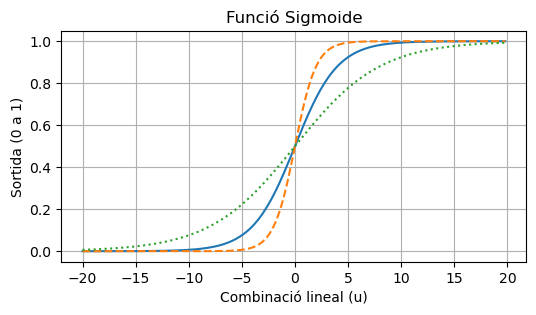

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z, alfa=1.0):
    return 1 / (1 + np.exp(-alfa * z))

# Generem valors per a la combinació lineal (eix X)
x = np.arange(-10, 10, 0.1) 
w1 = 2  # Pes per a la característica 1
alfa = 0.5 
z = w1 * x  # Combinació lineal

plt.figure(figsize=(6, 3))
plt.plot(z, sigmoid(z, alfa))
plt.plot(z, sigmoid(z, alfa*2), linestyle='--', label='alfa*2')
plt.plot(z, sigmoid(z, alfa/2), linestyle=':', label='alfa/2')
plt.title(f'Funció Sigmoide')
plt.xlabel('Combinació lineal (u)')
plt.ylabel('Sortida (0 a 1)')
plt.grid(True)
plt.show()

El codi anterior és una funció sigmoide a la que lo passem una z que sols té una variable i un pes. Normalment les neurones tindran més entrades. 

Una única neurona serveix tant per a classificació com per a regressió. En el primer cas sols hi ha que establir un `threshold` per al resultat del sigmoide i en el segon posant com a funció d'activació $f(x)=x$ de manera que no siga un `sigmoide`. 

Una xarxa neuronal no és res més que una col·lecció massiva d'aquestes petites peces (regressions lineals o logístiques) interconnectades en xarxa, on la sortida d'unes es converteix en l'entrada de les següents.

### Funcions d'activació 

L'objectiu del perceptron és ser activat o inhibit en determinades entrades. Si utilitzem el `threshold` l'eixida serà 0 o 1, però el punt d'activació serà distint en funció de la funció d'activació. 

Tenim les més simples que són les `lineal` i `step` i després la `sigmoide`, `Tanh`, `ReLu`... 

![funcions dactivacio](./funcionsactivacio.png)

Per a la classificació multiclasse s'utilitza `softmax`. Aquesta transforma la seua entrada en un vector de valors entre 0 i 1 que sumen 1. Es pot interpretar com la probabilitat de que l'entrada siga d'una classe determinada. Si traguem la posició del valor més alt, tenim la classe que ha predit el model i amés, tenim la confiança en que siga eixa classe. 

### Aprenentatge 

L'objectiu de l'aprenentatge és trobar la combinació de pesos que fa que tinga l'eixida correcta front a determinades entrades. Aixó ho fa amb un procés d'optimització d'una funció de perduda de manera que els pesos minimitzen l'error que comet la neurona o conjunt de neurones. 

L'algorisme de retropropagació és el més utilitzat. Aquest va actualitzant els pesos de forma iterativa:
1. Inicialització: Els pesos s'inicialitzen amb valors aleatoris
2. Feedforward: Entra un conjunt d'entrenament, es propaga per les neurones i s'obté l'eixida. 
3. Calcul de l'error: Es calcula l'error amb una funció de perduda (loss) que pot ser MAE, MSE o altres. Aquesta funció de cost calcula la diferència entre l'eixida prevista i la real.
4. Retropropagació (Backpropagation): A partir de la capa d'eixida es calcula la derivada de la funció de perduda respecte a cada pes. S'utilitza un concepte matemàtic anomenat `regla de la cadena` per a calcular les derivades parcials de l'ultima capa fins la primera. És el pas complicat perquè implica calcul diferencial.
5. Actualització de pesos: Mitjançant el `descens de gradient` es calcula la direcció en la que es redueix l'error i s'ajusten els pesos. La magnitid de l'ajust és la `tasa d'aprenentatge` o `learning rate`. 
6. Tornar al punt 2. 

Quan ja s'ha passat per totes les dades d'entrenament ha passat un `epoch`. Es poden fer varies `epoch`. 

Per a calcular l'error tenim moltes funcions de perduda que avaluen el funcionament de la xarxa. Triarem l'adequada per a cada tipus de problema. Aquestes són les més rellevants:

* Binary Cross Entropy (BCE) per a classificació binaria. 
* Cross Entropy (CE) per a classificació multiclasse. 
* Mean Squared Error (MSE) Per a regressió. 


## Xarxes neuronals



Si combinem varies neurones de manera que l'eixida d'unes entre en altres, podem resoldre regressions i classificacions que no siguen lineals. 

Les neurones s'agrupen en capes. Cada capa té `k` neurones i cadascuna rep les mateixes entrades. Hi ha 3 tipus de capes:

* Capa d'entrada (input layer) Rep i adapta les dades d'entrada. 
* Capes ocultes (hidden layers) Són capes intermedies entre la d'entrada i la d'eixida. Poden haber moltes. 
* Capa d'eixida (Output layer) És la capa final i proporciona la predicció. 

![xarxa neuronal](xarxa.png)

* El **perceptró** és una única capa que fa d'entrada i eixida. 
* La **red neuronal multicapa** són les que tenen entrada, capes oculte i exida. Es forma un grafo sense cicles (feedforward) 

Quan estem fent una xarxa neuronal el que realment creem són capes, ja que les neurones en particular són una unitat massa menuda. 

Les capes també són de distints tipus en funció de com s'organitzen les neurones i les entrades/eixides. 

El dissenyar una xarxa neuronal hem de veure l'estructura i tipus de dades de l'entrada i de l'eixida.

* Capa d'entrada: Les mateixes neurones que els atributs del dataset. Tots han de ser numèrics i si és categoric es codifica o es fa one-hot encoding. La funció d'activació pot ser `ReLu` per a classificació o `identitat` per a regressió. 
* Capes ocultes: No hi ha una regla general, s'ha de trobar un compromís entre el rendiment, precisió i Overfitting. No es recomana més del doble de neurones que l'entrada. 
* Capa d'eixida: Per a classificació binaria una neurona amb `sigmoide`. Per a multiclasse tantes neurones com classes i `softmax`. Per a regressió una neurona amb funció identitat. 

### Arquitectura de les xarxes neuronals

Si les neurones s'agrupen en capes i les capes en xarxes, aquestes tenen distintes arquitectures:

* Capes totalment connectades (fully connected): Formen xarxes denses on totes les neurones estan connectades a totes les de la següent capa. 
* Xarxes neuronals convolucionals: Estan especialitzades en dades bidimensionals com les imatges, les CNN utilitzen filtres convolucionals per extraure característiques locals de les imatges i combinar-les després. 
* Xarxes neuronals recurrents: RNN són arquitectures dissenyades per a seqüències de dades con paraules o series temporals. Les RNN tenen connexions recurrents, de manera que l'eixida també retroalimenta la xarxa, d'aquesta manera la següent predicció té memòria. Són la base del NLP, però han sigut superades.
* Xarxes neuronals generatives:  Com les Xarxes generatives antagòniques (GANs) o els Autoencoders. Entrenats de forma no supervisada, detecten patrons i són capaços de replicar imatges o textos similars. 
* Encoder/Decoder: Aprenen una representació compacta de les dades d'entrada i són capaços de "descomprimir" i recounstruir l'eixida. 
* Transformers: Són la base dels chatbots actuals, les que van suposar una revolució al NLP. 